In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2, ResNet50V2
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import cv2

from src import glob_vars

I0000 00:00:1790258162.063213    3599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790258164.769180    3599 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790258169.046010    3599 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Variables
ROOT_DIR = glob_vars['root_dir']
EPOCHS = glob_vars['epochs']
BATCH_SIZE = glob_vars['batch_size']
IMG_SIZE = glob_vars['input_size']
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)
ROTATION_DEGREE = glob_vars['rotation_range']

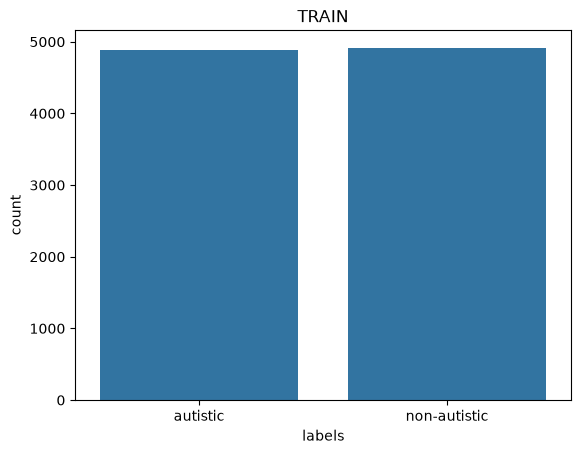

Train labels: 
labels
non-autistic    4912
autistic        4884
Name: count, dtype: int64


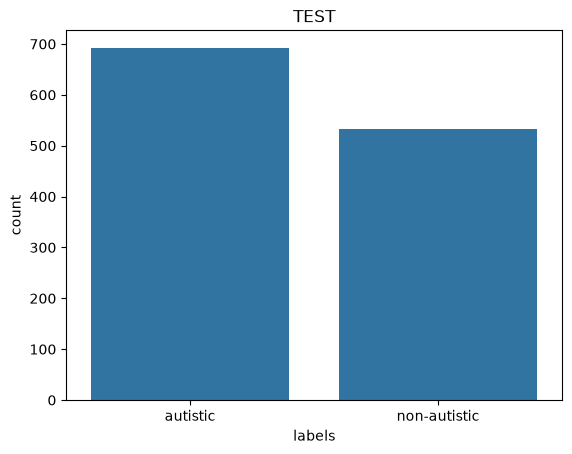

Test labels: 
labels
autistic        692
non-autistic    532
Name: count, dtype: int64


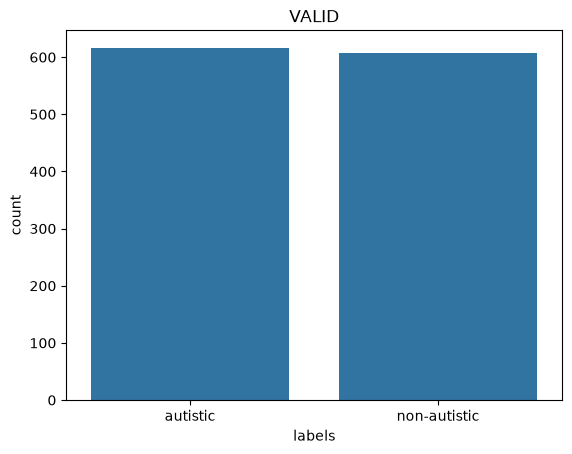

Valid labels: 
labels
autistic        616
non-autistic    608
Name: count, dtype: int64


In [3]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_train_80.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_test_10.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_valid_10.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
print(f"Train labels: ")
print(f"{train_df['labels'].value_counts()}")

sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
print(f"Test labels: ")
print(f"{test_df['labels'].value_counts()}")

sns.countplot(x='labels',data=valid_df)
plt.title('VALID')
plt.show()
print(f"Valid labels: ")
print(f"{valid_df['labels'].value_counts()}")

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=True
)

Found 9796 validated image filenames belonging to 2 classes.


In [5]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,       # Randomly rotates images by up to 20 degrees
    horizontal_flip=True,    # Flips images horizontally
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=False
)

Found 1224 validated image filenames belonging to 2 classes.


In [6]:
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuflle=True
)

Found 1224 validated image filenames belonging to 2 classes.


I0000 00:00:1790258186.624599    3599 gpu_device.cc:2042] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5861 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


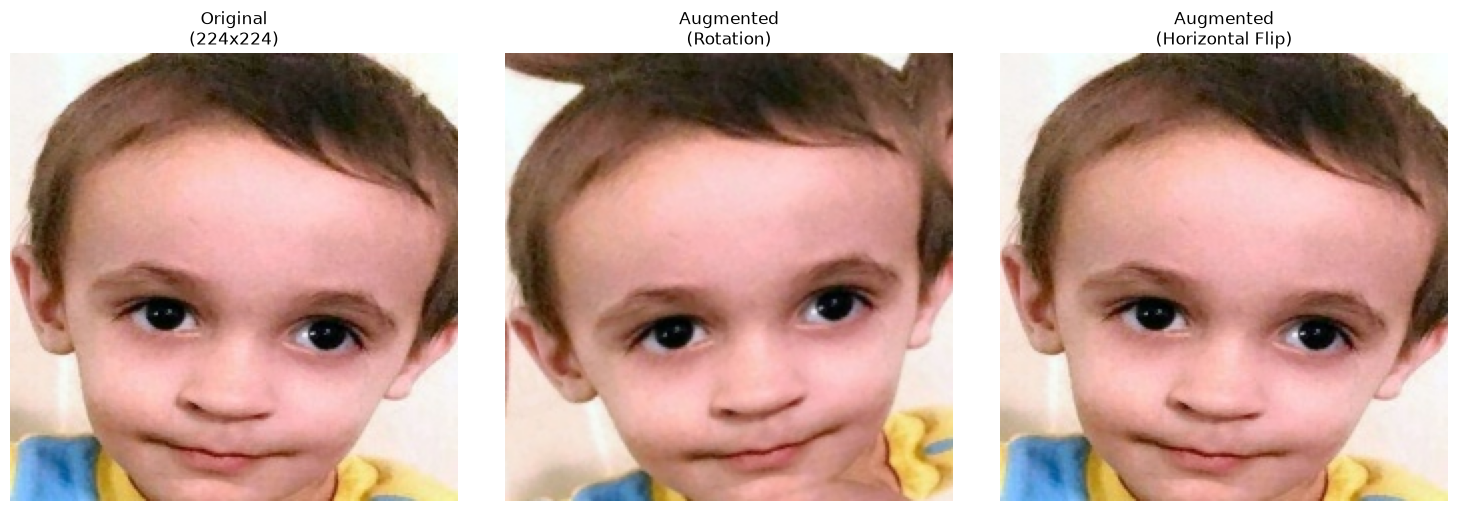

In [7]:
def visualisasi_preprocessing_aug(image_path):
    # 1. Load Original Image
    img_orig = cv2.imread(image_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    orig_shape = img_orig.shape
    
    # 2. Resize (Skenario Percobaan 1 & 3: 224x224)
    target_size = (224, 224)
    img_resized = cv2.resize(img_orig, target_size)
    
    # 3. Augmentasi (Horizontal Flip & Rotation)
    # Kita pake layer preprocessing Keras biar simpel
    data_augmentation_rotation = tf.keras.Sequential([
        # tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05), # Sekitar 72 derajat
    ])

    data_augmentation_flip = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        # tf.keras.layers.RandomRotation(0.2), # Sekitar 72 derajat
    ])
    
    # Tambah dimensi batch buat augmentasi (rotasi)
    img_aug_rotation = data_augmentation_rotation(tf.expand_dims(img_resized, 0))
    img_aug_rotation = tf.cast(img_aug_rotation[0], tf.uint8)

    # Tambah dimensi batch buat augmentasi (horizontal flip)
    img_aug_flip = data_augmentation_flip(tf.expand_dims(img_resized, 0))
    img_aug_flip = tf.cast(img_aug_flip[0], tf.uint8)

    # Plotting
    plt.figure(figsize=(15, 5))
    
    # # Tampilan Original
    # plt.subplot(1, 3, 1)
    # plt.imshow(img_orig)
    # plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    # plt.axis('off')
    
    # Tampilan Resized
    plt.subplot(1, 3, 1)
    plt.imshow(img_orig)
    plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    plt.axis('off')
    
    # Tampilan Augmented
    plt.subplot(1, 3, 2)
    plt.imshow(img_aug_rotation)
    plt.title("Augmented\n(Rotation)")
    plt.axis('off')

    # Tampilan Augmented
    plt.subplot(1, 3, 3)
    plt.imshow(img_aug_flip)
    plt.title("Augmented\n(Horizontal Flip)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_preprocessing_aug("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

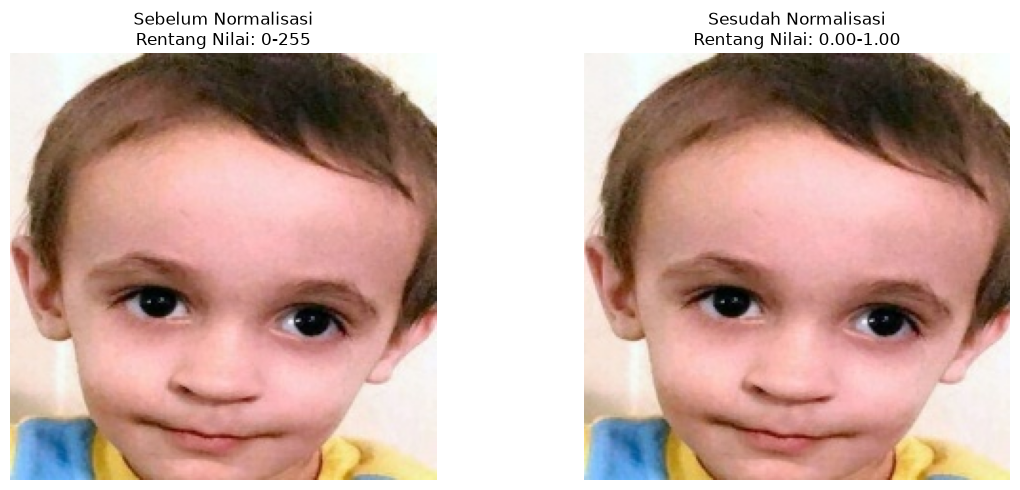

In [8]:
def visualisasi_normalisasi(img_path):
    # 1. Load Original (0-255)
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    
    # 2. Normalisasi (Contoh: Scaling ke [0, 1])
    # Di Deep Learning, ini ngebantu konvergensi model lebih cepet
    img_normalized = img_array / 255.0 
    
    # 3. Plotting perbandingan
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Sebelum Normalisasi
    ax[0].imshow(img_array.astype('uint8'))
    ax[0].set_title(f"Sebelum Normalisasi\nRentang Nilai: {int(np.min(img_array))}-{int(np.max(img_array))}")
    ax[0].axis('off')
    
    # Sesudah Normalisasi
    ax[1].imshow(img_normalized)
    ax[1].set_title(f"Sesudah Normalisasi\nRentang Nilai: {np.min(img_normalized):.2f}-{np.max(img_normalized):.2f}")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_normalisasi("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

In [9]:
# === CALLBACKS ===
checkpoint_a = ModelCheckpoint("asr_s5.keras", monitor="accuracy", save_best_only=True)
earlystop_a = EarlyStopping(monitor="accuracy", patience=glob_vars['early_stopping_patience'], restore_best_weights=True)

In [10]:
# --- BUILD DUAL-BACKBONE MODEL (FIXED) ---
num_classes = len(train_gen.class_indices)
# 1 single input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2 backbones: instantiate WITHOUT input_shape so they don't create their own Input layers
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet")

# Freeze both initially
mobilenet_backbone.trainable = False
resnet_backbone.trainable = False

# Call both backbones on the SAME input tensor
m_feat = mobilenet_backbone(inputs)      # feature map from MobileNet
r_feat = resnet_backbone(inputs)         # feature map from ResNet

# Pool and combine
m_pool = GlobalAveragePooling2D()(m_feat)
r_pool = GlobalAveragePooling2D()(r_feat)

combined = Concatenate()([m_pool, r_pool])
combined = Dense(512, activation="relu")(combined)
combined = Dropout(0.5)(combined)

outputs = Dense(1, activation="sigmoid")(combined)

/tmp/ipykernel_3599/3928226388.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")


In [11]:
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

# === TRAIN (Using learning rate 0.0001) ===
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[checkpoint_a, earlystop_a]
)

Epoch 1/100


I0000 00:00:1790258194.159618    3599 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1790258198.452059    3696 service.cc:154] XLA service 0x7f1ec456e670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790258198.452073    3696 service.cc:170]   StreamExecutor [0]: NVIDIA GeForce RTX 5060, Compute Capability 12.0a (Driver: 13.4.0[615.71.9]; Runtime: 13.0.0; Toolkit: 13.0.0; DNN: 9.19.1)
I0000 00:00:1790258198.586495    3696 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790258199.862021    3696 cuda_dnn.cc:436] Loaded cuDNN version 91901
E0000 00:00:1790258212.031303    3803 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258224.103520    3801 cuda_timer.cc:88] Delay kernel timed ou

  1/307 ━━━━━━━━━━━━━━━━━━━━ 2:58:46 35s/step - accuracy: 0.4688 - loss: 1.1137

W0000 00:00:1790258229.202382    3778 prefetch_dataset_op.cc:476] SEVERE STARVATION: Element UID 1790258198446532185 in buffer 'PrefetchDataset/_4' sat unconsumed for 30.3159 seconds!


188/307 ━━━━━━━━━━━━━━━━━━━━ 42s 354ms/step - accuracy: 0.7158 - loss: 0.5618

E0000 00:00:1790258299.156582    5113 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258299.352537    5113 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258299.557031    5113 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258299.755777    5113 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258300.039153    5117 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000

307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7386 - loss: 0.5294

E0000 00:00:1790258340.993949    6351 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258342.240179    6355 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258342.590358    6355 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258342.767720    6355 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790258345.041361    6355 cuda_timer.cc:88] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000

307/307 ━━━━━━━━━━━━━━━━━━━━ 155s 390ms/step - accuracy: 0.7386 - loss: 0.5294 - val_accuracy: 0.7941 - val_loss: 0.4368
Epoch 2/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 52s 170ms/step - accuracy: 0.7978 - loss: 0.4302 - val_accuracy: 0.8211 - val_loss: 0.3951
Epoch 3/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 53s 172ms/step - accuracy: 0.8213 - loss: 0.3868 - val_accuracy: 0.8203 - val_loss: 0.3850
Epoch 4/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 53s 172ms/step - accuracy: 0.8428 - loss: 0.3540 - val_accuracy: 0.8440 - val_loss: 0.3525
Epoch 5/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 52s 169ms/step - accuracy: 0.8529 - loss: 0.3297 - val_accuracy: 0.8521 - val_loss: 0.3166
Epoch 6/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 52s 170ms/step - accuracy: 0.8647 - loss: 0.3115 - val_accuracy: 0.8538 - val_loss: 0.3260
Epoch 7/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 53s 172ms/step - accuracy: 0.8766 - loss: 0.2913 - val_accuracy: 0.8791 - val_loss: 0.2966
Epoch 8/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 52s 169ms/step - accuracy: 0.8865 - loss: 0.27

In [15]:
# === EVALUATION ===
loss, acc = model.evaluate(test_gen)
print(f"\n🔥 Model Accuracy: {acc * 100:.2f}%")
# print(f"📉 Model Loss: {loss:.4f}")

error_rate = (1 - acc) * 100
print(f"❌ Error Rate: {error_rate:.2f}%")

39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.9828 - loss: 0.0521

🔥 Model Accuracy: 98.28%
❌ Error Rate: 1.72%


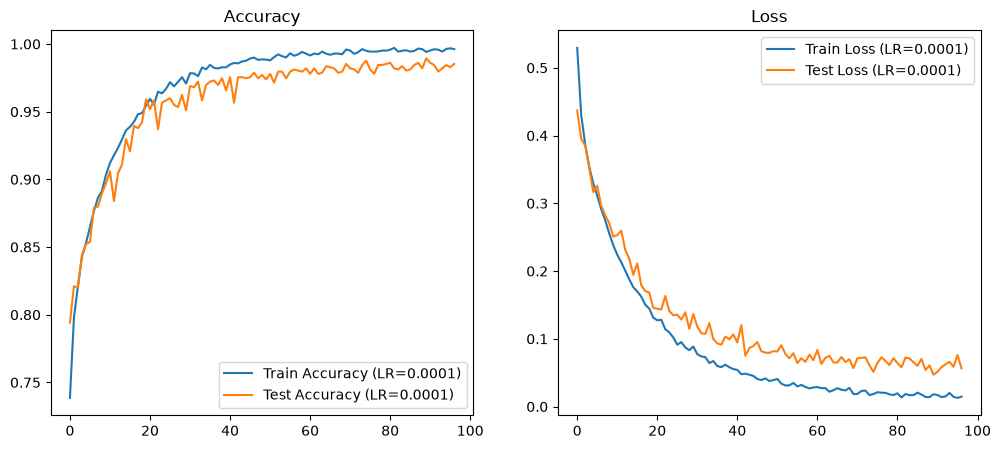

In [13]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy (LR=0.0001)")
plt.plot(history.history["val_accuracy"], label="Test Accuracy (LR=0.0001)")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss (LR=0.0001)")
plt.plot(history.history["val_loss"], label="Test Loss (LR=0.0001)")
plt.title("Loss")
plt.legend()

plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step
              precision    recall  f1-score   support

    autistic       0.98      0.99      0.98       692
non-autistic       0.98      0.97      0.98       532

    accuracy                           0.98      1224
   macro avg       0.98      0.98      0.98      1224
weighted avg       0.98      0.98      0.98      1224



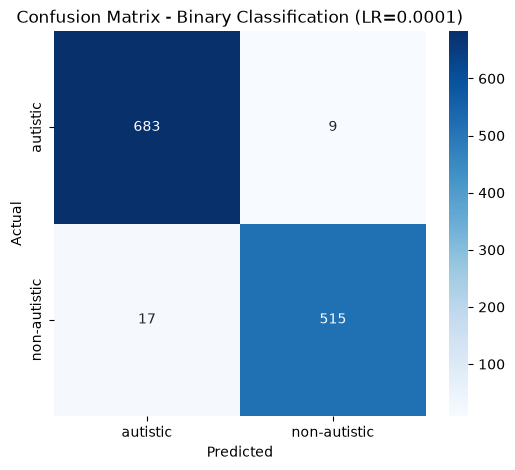

In [14]:
# 1. Ambil prediksi dalam bentuk probabilitas (0.0 sampai 1.0)
y_pred = model.predict(test_gen)

# 2. Ubah probabilitas jadi 0 atau 1 pake threshold 0.5
# Jangan pake argmax buat binary (1 output node)!
y_pred_class = (y_pred > 0.5).astype("int32").flatten()

# 3. Ambil label asli (ground truth)
y_true = test_gen.classes  
class_labels = list(test_gen.class_indices.keys())

# Sekarang print report-nya, pasti lebih masuk akal
print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_true, y_pred_class)

# Visualisasi tetep sama, tapi isinya udah bener
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Binary Classification (LR=0.0001)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()